# Batch TCA Pipeline

Runs TCA with 4 replicas and 10 components for each target file and alignment (tunnel entrance, sound cue).
Saves ensembles in the same format as tpca.ipynb (pickle with metadata). Loads, visualizes, and saves figures.

**Step 1:** Paths, imports, load one target's spikes + behavior.  
**Step 2:** Build 3D tensor (neurons × time × trials) with small buffer + subset of trials.  
**Step 3:** Run TCA on small tensor (ranks 1–3, 2 replicas), compute elbow + best_rep_idx, plot objective/similarity.  
**Step 4:** Save payload (tpca format + ordering + trial metadata) to pickle; load and verify.  
**Step 5:** Load from pickle and visualize factors (same grid and colors as tpca: U scatter, V line, W scatter; TrialStim palette; area if in payload).

## Imports and paths

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

# Resolve project root (folder containing 'data')
base = Path.cwd()
for p in [base, *base.parents]:
    if (p / 'data').exists():
        project_root = p
        break
else:
    project_root = base

data_root = str(project_root / 'data')
results_dir = project_root / 'results' / '4replicas_10components_10frames'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {data_root}")
print(f"Results dir: {results_dir}")

Data root: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data
Results dir: /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames


## Target files and behavior paths

In [2]:
# Same target identifiers as Batch_TCA_Runner and tpca
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'
unsup_bef = 'TX105_2022_10_08_2'
unsup_aft = 'TX105_2022_10_19_2'

def get_beh_path(target_file):
    """Return behavior .npy filename for a target file."""
    if target_file == sup_bef:
        return 'Beh_sup_train1_before_learning.npy'
    if target_file == sup_aft:
        return 'Beh_sup_train1_after_learning.npy'
    if target_file == unsup_bef:
        return 'Beh_unsup_train1_before_learning.npy'
    if target_file == unsup_aft:
        return 'Beh_unsup_train1_after_learning.npy'
    raise ValueError(f"Unknown target_file: {target_file}")

# For Step 1 we use a single target
target_file = sup_bef
beh_filename = get_beh_path(target_file)
beh_path = os.path.join(data_root, beh_filename)
spike_path = os.path.join(data_root, target_file + '_SVD_dec.npy')

print(f"Target: {target_file}")
print(f"Spike file: {spike_path}")
print(f"Beh file: {beh_path}")

Target: VR2_2021_03_20_1
Spike file: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data/VR2_2021_03_20_1_SVD_dec.npy
Beh file: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data/Beh_sup_train1_before_learning.npy


## Load spikes and behavior (one target)

In [3]:
# Load spike data (SVD-decomposed)
# U.T @ V gives (n_neurons, n_time); transpose so time is first axis for create_3d_matrix
svd_data = np.load(spike_path, allow_pickle=True).item()
spikes = (svd_data['U'].T @ svd_data['V']).T  # (n_timepoints, n_neurons)

# Load behavior for this target
beh_all = np.load(beh_path, allow_pickle=True).item()
beh = beh_all[target_file]

n_timepoints, n_neurons = spikes.shape
print(f"Spikes shape: {spikes.shape} = ({n_timepoints} timepoints x {n_neurons} neurons)")
print(f"Behavior keys: {list(beh.keys())[:10]}... (total {len(beh)} keys)")

Spikes shape: (24298, 81473) = (24298 timepoints x 81473 neurons)
Behavior keys: ['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime']... (total 59 keys)


## Neuron area from trans file (before TCA)

Load the trans file for this recording and build `neuron_to_area` (neuron index → area name), same logic as tpca's `add_area_label_to_melted_spikes`. Required so we can save it in the payload and use it in factor visualization.

In [4]:
def load_neuron_to_area_from_trans(root, recording_name):
    """Load trans file and return Series mapping neuron index (0..n-1) → area name. Same iarea→area map as tpca."""
    # Trans file: recording_name with last character removed + 'trans.npz' (e.g. VR2_2021_03_20_1 → VR2_2021_03_20_trans.npz)
    filename = os.path.join(root, recording_name[:-1] + "trans.npz")
    with np.load(filename, allow_pickle=True) as retin:
        retin_df = pd.DataFrame({"iarea": retin["iarea"]})
    retin_df["neuron"] = retin_df.index.astype(int)
    # Same area mapping as tpca
    area_map_dict = pd.Series({
        8: "V1", 0: "mHV", 1: "mHV", 2: "mHV", 9: "mHV",
        5: "lHV", 6: "lHV", 3: "aHV", 4: "aHV",
    })
    retin_df["area"] = retin_df["iarea"].map(area_map_dict).fillna("Other")
    neuron_to_area = retin_df.set_index("neuron")["area"]
    return neuron_to_area

neuron_to_area = load_neuron_to_area_from_trans(data_root, target_file)
# Sanity check: length should match n_neurons from spikes
assert len(neuron_to_area) == n_neurons, f"Trans neurons {len(neuron_to_area)} vs spike neurons {n_neurons}"
print(f"neuron_to_area: {len(neuron_to_area)} neurons, areas: {neuron_to_area.unique().tolist()}")

neuron_to_area: 81473 neurons, areas: ['V1', 'Other', 'lHV', 'aHV', 'mHV']


## Sanity check: alignment timestamps (one trial)

In [5]:
# Buffers we will use later: tunnel (2 before, 8 after), sound (5 before, 5 after)
BUFFER_TUNNEL = (2, 8)   # frames before/after tunnel entrance (Trial_start_time)
BUFFER_SOUND = (5, 5)    # frames before/after sound cue (SoundTime)

# One trial: show Trial_start_time and SoundTime
trial_idx = 0
t_start = beh['Trial_start_time'][trial_idx]
t_sound = beh['SoundTime'][trial_idx]
ft = beh['ft'][: min(len(beh['ft']), spikes.shape[0] + 1)]

print(f"Trial {trial_idx}: Trial_start_time = {t_start}, SoundTime = {t_sound}")
print(f"Behavior 'ft' length: {len(ft)}, spikes timepoints: {spikes.shape[0]}")
print(f"Number of trials (Trial_start_time): {len(beh['Trial_start_time'])}")

Trial 0: Trial_start_time = 738235.7096927778, SoundTime = 738235.7097275
Behavior 'ft' length: 24299, spikes timepoints: 24298
Number of trials (Trial_start_time): 348


## Step 2: Build 3D tensor (neurons × time × trials)

`create_3d_matrix` returns shape **(n_neurons, n_time, n_trials)** so TCA factors are (U, V, W) = (neurons, time, trials) with no transpose.  
We test with a **small buffer** and **subset of trials** to verify shapes.

In [6]:
def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
    """
    Build 3D tensor for TCA with shape (n_neurons, n_time, n_trials).
    So TCA factors will be U (neurons), V (time), W (trials) with no reordering.

    trial_timestamps: array of timestamps to center each trial window on
    buffer: (n_before, n_after) frames left/right of the timestamp
    spiking_data: (n_timepoints, n_neurons)
    spiking_timestamps: timestamps for each row of spiking_data
    """
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    n_neurons = spiking_data.shape[1]
    tensor = np.zeros((n_neurons, n_time, n_trials), dtype=np.float32)
    for index, timestamp in enumerate(trial_timestamps):
        idx = np.searchsorted(spiking_timestamps, timestamp, side='right')
        # slice (n_time,) x (n_neurons); .T -> (n_neurons, n_time)
        tensor[:, :, index] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :].T
    return tensor

In [7]:
# Step 2 test: small buffer and subset of trials (run after loading spikes + beh above)
ft = beh['ft'][: spikes.shape[0] + 1]
trial_timestamps = beh['Trial_start_time']

# Small test: 4 time frames (1 before + 2 after center), 20 trials
buffer_small = (1, 2)   # 1 + 2 + 1 = 4 frames
n_trials_test = 20
trial_ts_test = trial_timestamps[:n_trials_test]

tensor_small = create_3d_matrix(trial_ts_test, buffer_small, spikes, ft)
n_neurons, n_time, n_trials = tensor_small.shape
print(f"Tensor shape: {tensor_small.shape} = (n_neurons={n_neurons}, n_time={n_time}, n_trials={n_trials})")
print(f"Min: {tensor_small.min():.4f}, Max: {tensor_small.max():.4f}, Mean: {tensor_small.mean():.4f}")

Tensor shape: (81473, 4, 20) = (n_neurons=81473, n_time=4, n_trials=20)
Min: -4.6964, Max: 63.2552, Mean: 0.2767


## Step 3: Run TCA and compute best rank (elbow)

Fit ensemble on the small tensor with ranks 1–3 and 2 replicas. Compute mean reconstruction error per rank, best replicate per rank, and elbow-based `best_rank`. Plot objective and similarity with **descriptive titles** (target, alignment, buffer, rank range, replicates, best_rank) and **save** the figure to `results/4replicas_10components_10frames/` using the naming convention:  
`objective_similarity_{target_file}_{alignment}_buffer{n}-{n}_r{min}-{max}_rep{n}_best{n}.png`

Fitting rank-1 models:   0%|          | 0/2 [00:00<?, ?it/s]/Users/johnmadrid/miniconda3/envs/isp-unsupervised-learning/lib/python3.9/site-packages/tensortools/optimize/ncp_hals.py:185: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  Cp = factors[:, idx] @ grams[idx][:, p]
                                                                    

Rank-1 models:  min obj, 0.82;  max obj, 0.82;  time to fit, 0.9s


Rank-2 models:  min obj, 0.74;  max obj, 0.74;  time to fit, 1.7s


Rank-3 models:  min obj, 0.69;  max obj, 0.69;  time to fit, 2.0s


Plot saved to /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/objective_similarity_VR2_2021_03_20_1_Trial_start_time_buffer1-2_r1-3_rep2_best2.png


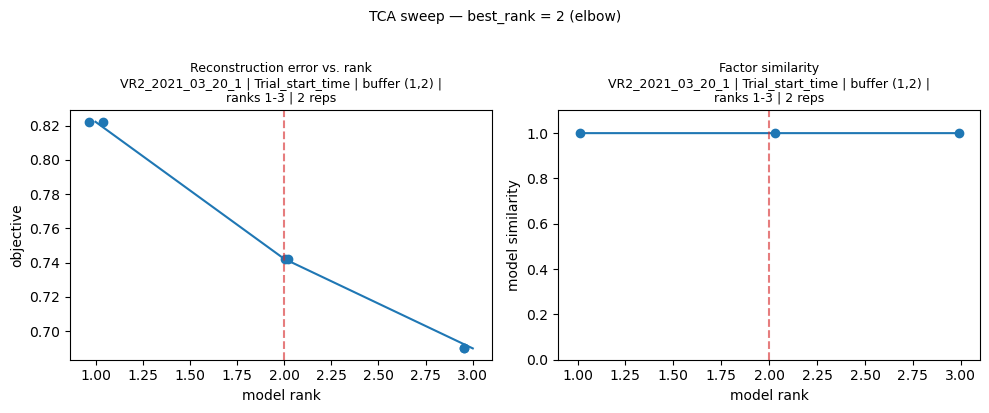

Selected best_rank = 2 (elbow on reconstruction error)
best_rep_idx = {1: 0, 2: 0, 3: 0}


In [8]:
# Compatibility: scipy.random was removed in recent SciPy; tensortools still uses it
import scipy
if not hasattr(scipy, 'random'):
    import numpy.random
    scipy.random = numpy.random

import tensortools as tt
import matplotlib.pyplot as plt

# Step 3: small rank range and replicates for quick test
rank_range = range(1, 4)   # ranks 1, 2, 3
replicates = 2

# Alignment and buffer used for this run (for titles and filename)
alignment_name = "Trial_start_time"  # tunnel entrance
buffer_used = buffer_small  # (1, 2) for Step 3 test

ensemble_rank_sweep = tt.Ensemble(fit_method="ncp_hals")
ensemble_rank_sweep.fit(tensor_small, ranks=rank_range, replicates=replicates)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tt.plot_objective(ensemble_rank_sweep, ax=axes[0])
tt.plot_similarity(ensemble_rank_sweep, ax=axes[1])

# Descriptive titles: target, alignment, buffer, rank range, replicates (wrap if long)
import textwrap
title_suffix = f"{target_file} | {alignment_name} | buffer ({buffer_used[0]},{buffer_used[1]}) | ranks {min(rank_range)}-{max(rank_range)} | {replicates} reps"
wrapped_suffix = textwrap.fill(title_suffix, width=55)
axes[0].set_title(f"Reconstruction error vs. rank\n{wrapped_suffix}", fontsize=9)
axes[1].set_title(f"Factor similarity\n{wrapped_suffix}", fontsize=9)

# Compute mean reconstruction error and best replicate per rank
orig_norm = np.linalg.norm(tensor_small)
mean_errors = []
best_rep_idx = {}
for r in rank_range:
    reps = ensemble_rank_sweep.factors(r)
    errs = []
    best_idx = 0
    best_err = None
    for i, (U, V, W) in enumerate(reps):
        if U.shape[0] == tensor_small.shape[0] and V.shape[0] == tensor_small.shape[1] and W.shape[0] == tensor_small.shape[2]:
            Xhat = np.einsum('ir,jr,kr->ijk', U, V, W)
        elif U.shape[1] == tensor_small.shape[0] and V.shape[1] == tensor_small.shape[1] and W.shape[1] == tensor_small.shape[2]:
            Xhat = np.einsum('ri,rj,rk->ijk', U, V, W)
        else:
            raise ValueError(f"Unexpected factor shapes for rank {r}: {[a.shape for a in (U, V, W)]}")
        err = np.linalg.norm(tensor_small - Xhat) / (orig_norm + 1e-12)
        errs.append(err)
        if best_err is None or err < best_err:
            best_err = err
            best_idx = i
    mean_errors.append(float(np.mean(errs)))
    best_rep_idx[int(r)] = int(best_idx)

# Elbow heuristic on error curve
x = np.arange(len(mean_errors), dtype=float) + 1.0
y = np.array(mean_errors, dtype=float)
m = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-12)
b = y[0] - m * x[0]
dist = np.abs(m * x + b - y) / (np.sqrt(m * m + 1.0) + 1e-12)
elbow_rank = int(x[np.argmax(dist)])
best_rank = int(max(1, elbow_rank))

for ax in axes:
    ax.axvline(best_rank, color='tab:red', linestyle='--', alpha=0.6)
fig.suptitle(f"TCA sweep — best_rank = {best_rank} (elbow)", fontsize=10, y=1.02)
plt.tight_layout()

# Save plot with naming convention: objective_similarity_{target}_{alignment}_buffer{b}-{b}_r{min}-{max}_rep{n}_best{best}.png
plot_filename = results_dir / (
    f"objective_similarity_{target_file}_{alignment_name}_buffer{buffer_used[0]}-{buffer_used[1]}_"
    f"r{min(rank_range)}-{max(rank_range)}_rep{replicates}_best{best_rank}.png"
)
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")
plt.show()

print(f"Selected best_rank = {best_rank} (elbow on reconstruction error)")
print(f"best_rep_idx = {best_rep_idx}")

## Step 4: Save payload (tpca format + ordering + metadata)

Save ensemble and all info needed for self-contained load and visualization: same keys as tpca plus neuron_order, frame_order, trial_order, beh_field, buffer, trial_to_stim, and neuron_to_area (from trans file, computed before TCA).

In [9]:
import pickle

# Dataset label (sup_bef, unsup_bef, etc.) for filename and payload
candidates = {"sup_bef": sup_bef, "sup_aft": sup_aft, "unsup_bef": unsup_bef, "unsup_aft": unsup_aft}
dataset_id = target_file
dataset_label = next((k for k, v in candidates.items() if v == dataset_id), "unknown")

# Ordering used in the tensor (must match tensor_small dimensions)
n_neurons, n_time, n_trials = tensor_small.shape
neuron_order = np.arange(n_neurons)  # neuron index in tensor = 0 .. n_neurons-1
frame_order = np.arange(n_time)       # time index = 0 .. n_time-1 (relative to alignment window)
trial_order = np.asarray(beh["trInd"][:n_trials_test], dtype=int)  # actual trial IDs for first n_trials_test trials

# TrialStim per trial (for visualization)
trial_to_stim = dict(zip(trial_order, beh["TrialStim"][:n_trials_test]))

# Filename: same style as tpca, plus alignment and buffer for clarity
fname = (
    f"ensemble_{dataset_label}_{dataset_id}_{alignment_name}_buffer{buffer_used[0]}-{buffer_used[1]}_"
    f"{ensemble_rank_sweep._fit_method.__name__}_"
    f"r{min(rank_range)}-{max(rank_range)}_rep{replicates}.pkl"
)
save_path = results_dir / fname

payload = {
    "ensemble": ensemble_rank_sweep,
    "best_rank": int(best_rank),
    "rank_range": list(rank_range),
    "replicates": int(replicates),
    "best_rep_idx": {int(k): int(v) for k, v in best_rep_idx.items()},
    "dataset_label": dataset_label,
    "dataset_id": dataset_id,
    "spike_file": spike_path,
    "beh_path": beh_path,
    "neuron_order": neuron_order,
    "frame_order": frame_order,
    "trial_order": trial_order,
    "beh_field": alignment_name,
    "buffer": tuple(buffer_used),
    "trial_to_stim": trial_to_stim,
    "neuron_to_area": neuron_to_area,
}

with open(save_path, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {save_path}")
print(f"Payload keys: {list(payload.keys())}")

Saved: /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/ensemble_sup_bef_VR2_2021_03_20_1_Trial_start_time_buffer1-2_ncp_hals_r1-3_rep2.pkl
Payload keys: ['ensemble', 'best_rank', 'rank_range', 'replicates', 'best_rep_idx', 'dataset_label', 'dataset_id', 'spike_file', 'beh_path', 'neuron_order', 'frame_order', 'trial_order', 'beh_field', 'buffer', 'trial_to_stim', 'neuron_to_area']


In [10]:
# Load and verify saved payload
with open(save_path, "rb") as f:
    loaded = pickle.load(f)

print("Loaded keys:", list(loaded.keys()))
print("best_rank:", loaded["best_rank"], "| best_rep_idx:", loaded["best_rep_idx"])
print("neuron_order len:", len(loaded["neuron_order"]), "| frame_order len:", len(loaded["frame_order"]), "| trial_order len:", len(loaded["trial_order"]))
print("trial_to_stim sample:", dict(list(loaded["trial_to_stim"].items())[:5]))
# Quick shape check: factors for best_rank should match ordering lengths
R = loaded["best_rank"]
rep_idx = loaded["best_rep_idx"].get(R, 0)
factors = loaded["ensemble"].factors(R)[rep_idx]
U, V, W = factors
assert U.shape[0] == len(loaded["neuron_order"]) and V.shape[0] == len(loaded["frame_order"]) and W.shape[0] == len(loaded["trial_order"]), "Factor shapes don't match ordering"
print("Factor shapes match ordering. OK.")

Loaded keys: ['ensemble', 'best_rank', 'rank_range', 'replicates', 'best_rep_idx', 'dataset_label', 'dataset_id', 'spike_file', 'beh_path', 'neuron_order', 'frame_order', 'trial_order', 'beh_field', 'buffer', 'trial_to_stim', 'neuron_to_area']
best_rank: 2 | best_rep_idx: {1: 0, 2: 0, 3: 0}
neuron_order len: 81473 | frame_order len: 4 | trial_order len: 20
trial_to_stim sample: {np.int64(0): np.str_('leaf1'), np.int64(1): np.str_('leaf1'), np.int64(2): np.str_('circle1'), np.int64(3): np.str_('leaf1'), np.int64(4): np.str_('circle1')}
Factor shapes match ordering. OK.


## Step 5: Visualize factors (load from pickle, same grid as tpca)

Load the saved payload, get factors for `best_rank`, and plot the component grid: U (neurons) scatter, V (time) line, W (trials) scatter. Same layout, y-limits, and TrialStim palette as tpca. Neuron panel uses `neuron_to_area` from payload if present, else a single group.

Plot saved to /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/tensor_components_grid_sup_bef_VR2_2021_03_20_1_Trial_start_time_buffer1-2.png


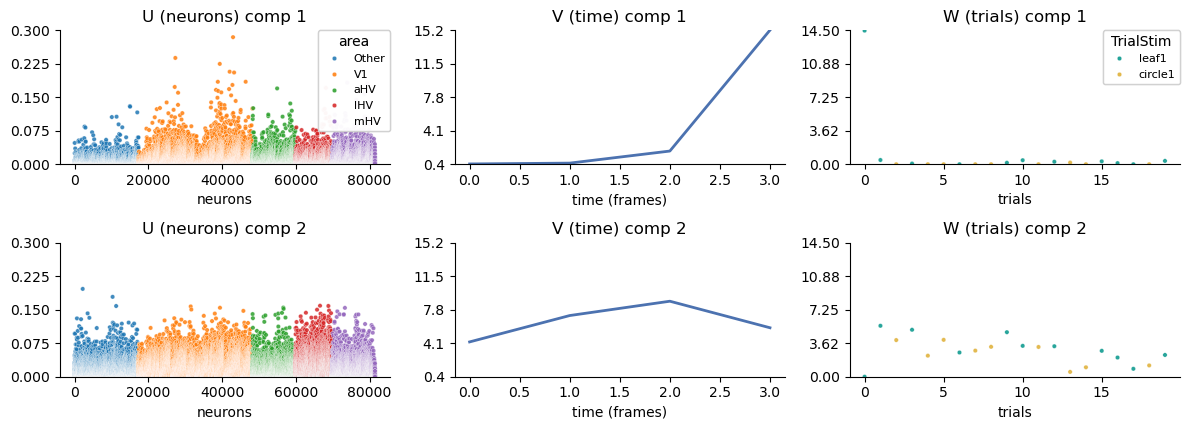

In [11]:
# Load from pickle (use save_path from Step 4, or set load_path to a specific file)
import matplotlib.pyplot as plt
import seaborn as sns

load_path = save_path  # or e.g. results_dir / "ensemble_sup_bef_..._r1-3_rep2.pkl"
with open(load_path, "rb") as f:
    data = pickle.load(f)

# Factors and ordering
R = data["best_rank"]
rep_idx = data["best_rep_idx"].get(R, 0)
factors = data["ensemble"].factors(R)[rep_idx]
aU, aV, aW = factors  # (n_neurons, R), (n_time, R), (n_trials, R)
neuron_order = data["neuron_order"]
frame_order = data["frame_order"]
trial_order = data["trial_order"]
trial_to_stim = data["trial_to_stim"]
if isinstance(trial_to_stim, dict):
    trial_to_stim = pd.Series(trial_to_stim)

# Neuron→area: use from payload if present, else single group for consistent layout
neuron_to_area = data.get("neuron_to_area")
if neuron_to_area is None:
    neuron_to_area = pd.Series("n/a", index=neuron_order)
elif isinstance(neuron_to_area, dict):
    neuron_to_area = pd.Series(neuron_to_area)

# Same grid and style as tpca
fig_height = max(2.5, min(2.2 * R, 18))
fig, axes = plt.subplots(R, 3, figsize=(12, fig_height), sharex=False)
if R == 1:
    axes = np.array([axes])

u_min, u_max = round(float(np.nanmin(aU)), 1), round(float(np.nanmax(aU)), 1)
v_min, v_max = round(float(np.nanmin(aV)), 1), round(float(np.nanmax(aV)), 1)
w_min, w_max = round(float(np.nanmin(aW)), 1), round(float(np.nanmax(aW)), 1)

for k in range(R):
    # U (neurons): scatter, colored by area
    ax0 = axes[k, 0]
    neu_df = pd.DataFrame({"neuron": neuron_order, "loading": aU[:, k]})
    neu_df["area"] = neu_df["neuron"].map(neuron_to_area)
    neu_df = neu_df.sort_values(["area", "neuron"]).reset_index(drop=True)
    neu_df["neuron_idx"] = np.arange(len(neu_df))
    sns.scatterplot(data=neu_df, x="neuron_idx", y="loading", hue="area", s=10, alpha=0.85,
                    ax=ax0, legend=(k == 0))
    ax0.set_title(f"U (neurons) comp {k+1}")
    ax0.set_xlabel("neurons")
    ax0.set_ylabel("")
    ax0.set_ylim(u_min, u_max)
    ax0.set_yticks(np.linspace(u_min, u_max, num=5))
    sns.despine(ax=ax0, top=True, right=True)

    # V (time): line
    ax1 = axes[k, 1]
    time_df = pd.DataFrame({"frame": frame_order, "loading": aV[:, k]})
    sns.lineplot(data=time_df, x="frame", y="loading", ax=ax1, color=sns.color_palette("deep")[0], linewidth=2)
    ax1.set_title(f"V (time) comp {k+1}")
    ax1.set_xlabel("time (frames)")
    ax1.set_ylabel("")
    ax1.set_ylim(v_min, v_max)
    ax1.set_yticks(np.linspace(v_min, v_max, num=5))
    sns.despine(ax=ax1, top=True, right=True)

    # W (trials): scatter, colored by TrialStim (same palette as tpca)
    ax2 = axes[k, 2]
    tr_df = pd.DataFrame({"ft_trInd": trial_order, "loading": aW[:, k]})
    tr_df["TrialStim"] = tr_df["ft_trInd"].map(trial_to_stim)
    custom_trialstim_palette = {"circle1": "#DFAE32", "leaf1": "#02968a"}
    sns.scatterplot(data=tr_df, x="ft_trInd", y="loading", hue="TrialStim", s=10, alpha=0.85,
                    ax=ax2, legend=(k == 0), palette=custom_trialstim_palette)
    ax2.set_title(f"W (trials) comp {k+1}")
    ax2.set_xlabel("trials")
    ax2.set_ylabel("")
    ax2.set_ylim(w_min, w_max)
    ax2.set_yticks(np.linspace(w_min, w_max, num=5))
    sns.despine(ax=ax2, top=True, right=True)

# Legends on first row only (same as tpca)
if R >= 1:
    leg0 = axes[0, 0].legend(title="area", fontsize=8, loc="upper right", borderaxespad=0.0)
    if leg0 is not None:
        axes[0, 0].add_artist(leg0)
    leg2 = axes[0, 2].legend(title="TrialStim", fontsize=8, loc="upper right", borderaxespad=0.0)
    if leg2 is not None:
        axes[0, 2].add_artist(leg2)

plt.tight_layout()
plot_filename = results_dir / (
    f"tensor_components_grid_{data['dataset_label']}_{data['dataset_id']}_{data['beh_field']}_"
    f"buffer{data['buffer'][0]}-{data['buffer'][1]}.png"
)
plt.savefig(plot_filename, dpi=150, bbox_inches="tight")
print(f"Plot saved to {plot_filename}")
plt.show()